<a href="https://colab.research.google.com/github/UKD1211/100_days_ML_cX_ISI_DS/blob/main/Projects_ML/Medical_insurance_cost_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso,SGDRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/medical_insurance.csv')

In [129]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [ ]:
df.sample(10)


,age,sex,bmi,children,smoker,region,charges
2111,30,female,39.050,3,yes,southeast,40932.42950
244,63,female,27.740,0,yes,northeast,29523.16560
1674,59,female,36.765,1,yes,northeast,47896.79135
1052,49,male,29.830,1,no,northeast,9288.02670
1189,23,female,28.000,0,no,southwest,13126.67745
2468,38,male,19.950,1,no,northwest,5855.90250
419,63,female,26.980,0,yes,northwest,28950.46920
1706,34,male,25.270,1,no,northwest,4894.75330
1555,27,male,18.905,3,no,northeast,4827.90495
1120,23,female,31.400,0,yes,southwest,34166.27300


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [ ]:
print(df['sex'].value_counts())
print(df['children'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      1406
female    1366
Name: count, dtype: int64
children
0    1186
1     672
2     496
3     324
4      52
5      42
Name: count, dtype: int64
smoker
no     2208
yes     564
Name: count, dtype: int64
region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64


/tmp/ipykernel_886/1108686981.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


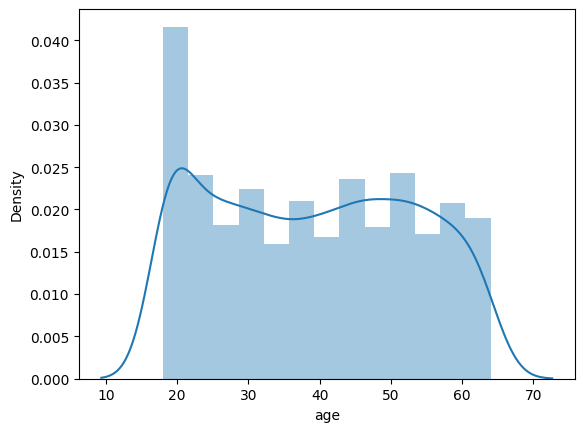

In [ ]:
# AGE
sns.distplot(df['age'])
plt.show()

<Axes: xlabel='age', ylabel='bmi'>

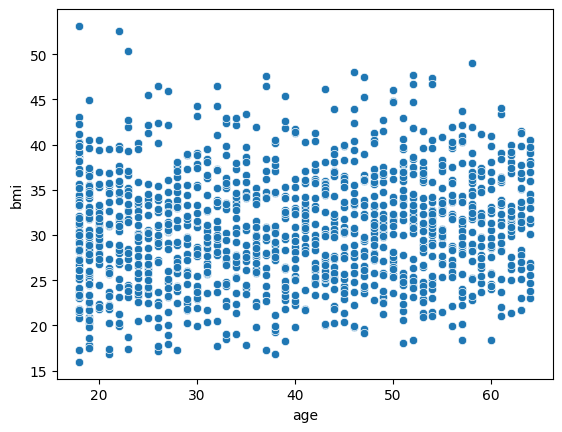

In [ ]:
sns.scatterplot(x = df['age'],y=df['bmi'])

In [ ]:
df['age'].corr(df['bmi'])

np.float64(0.11304845107996202)

In [ ]:
df['age']

,age
0,19
1,18
2,28
3,33
4,32
...,...
2767,47
2768,21
2769,19
2770,23


In [ ]:
df['age'].corr(df['charges'])

np.float64(0.2986236656293629)

<Axes: xlabel='age', ylabel='charges'>

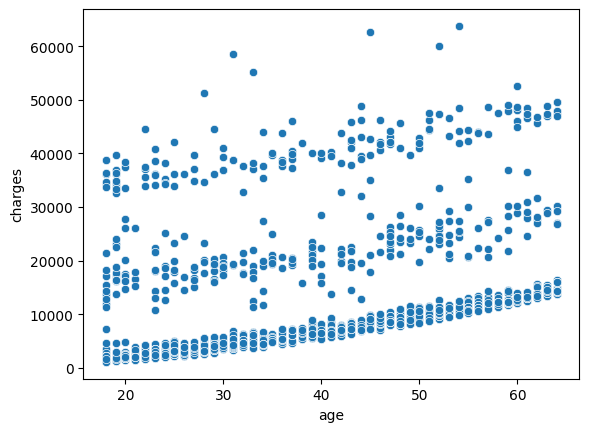

In [ ]:
sns.scatterplot(x = df['age'],y=df['charges'])

<Axes: ylabel='age'>

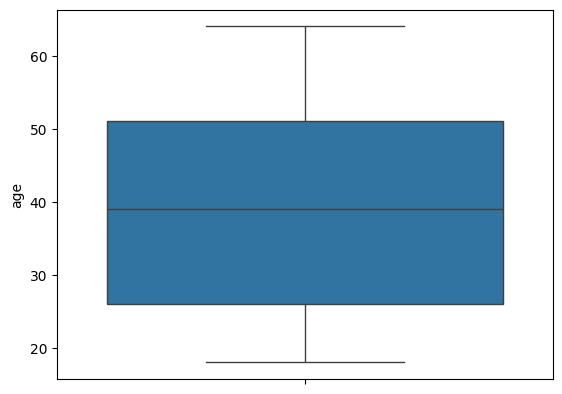

In [ ]:
sns.boxplot(df['age'])

# Age is a valid, well-behaved continuous predictor with an approximately linear relationship to charges; it requires no transformation or scaling, but its effect is likely conditional on subgroup variables (e.g., smoker status).

<Axes: xlabel='sex', ylabel='count'>

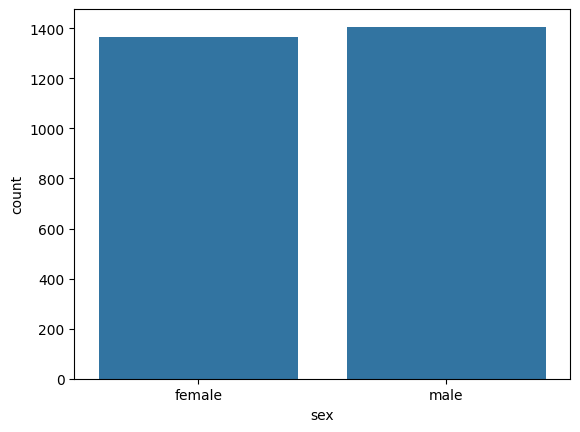

In [ ]:
# SEX
sns.countplot(x='sex', data=df)

In [ ]:
df.groupby('sex')['charges'].mean()

,charges
sex,
female,12486.831977
male,14013.872721


<Axes: xlabel='sex', ylabel='charges'>

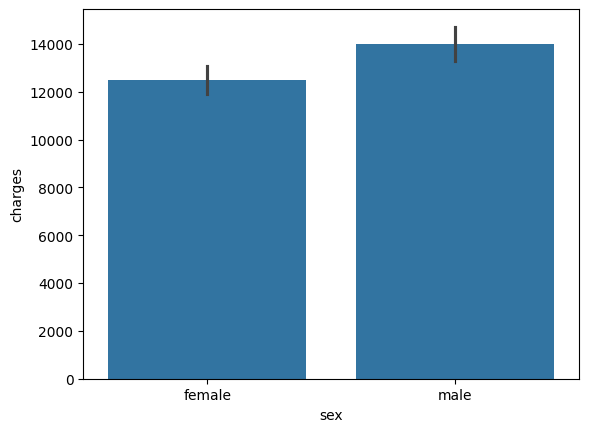

In [ ]:
sns.barplot(x='sex', y='charges', data=df)

In [ ]:
df.groupby('sex')['bmi'].mean()

,bmi
sex,
female,30.434473
male,30.960633


# Sex: binary categorical variable with balanced classes; shows a small difference in mean charges and requires only OHE later, no further preprocessing.

In [ ]:
#BMI = body mass index

/tmp/ipykernel_886/4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

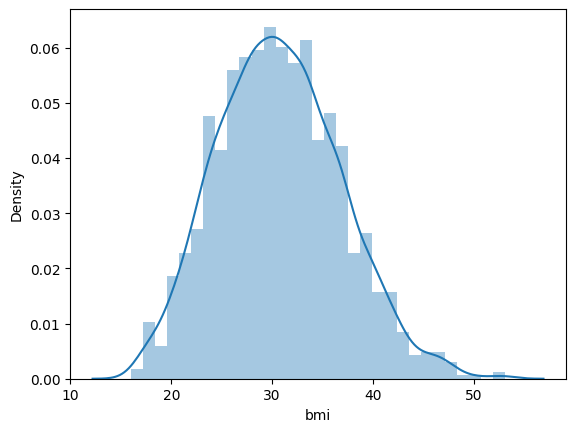

In [ ]:
sns.distplot(df['bmi'])

In [ ]:
df['bmi'].mean()

np.float64(30.70134920634921)

In [ ]:
df['bmi'].corr(df['charges'])

np.float64(0.19984604873978873)

<Axes: xlabel='bmi', ylabel='charges'>

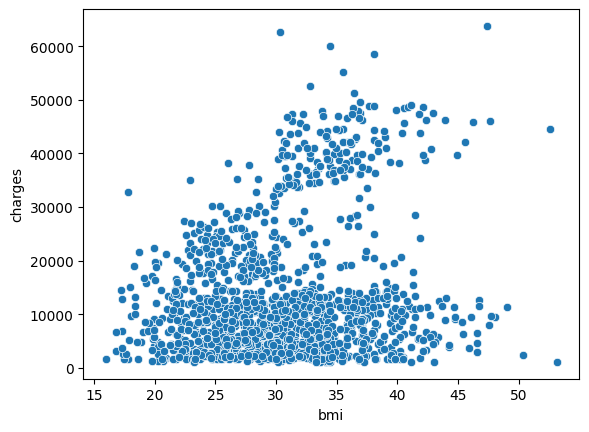

In [ ]:
sns.scatterplot(x = df['bmi'],y = df['charges'])

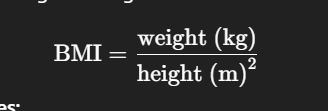

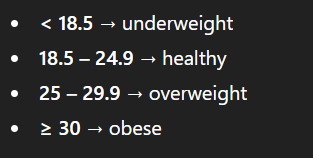  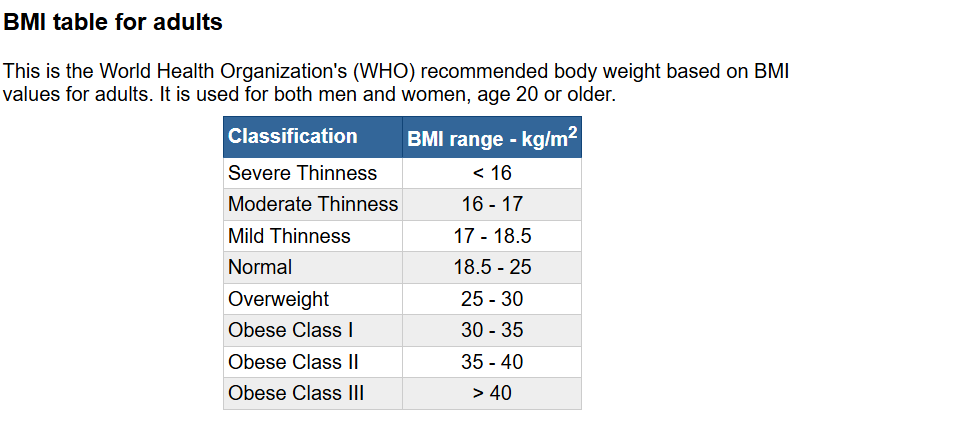

In [ ]:
df[df['bmi'] >= 30].shape[0]/df.shape[0]*100

53.03030303030303

# Approximately 53% of individuals in the insurance dataset have BMI ≥ 30, indicating a strong overrepresentation of high-risk individuals, consistent with the cost-focused nature of the data rather than population prevalence.

In [ ]:
obese_mean = df[df['bmi'] >= 30]['charges'].mean()
underweight_mean = df[df['bmi'] < 18.5]['charges'].mean()
healty_mean = df[(df['bmi'] >= 18.5 ) & (df['bmi'] <= 24.9)]['charges'].mean()
overweight_mean = df[(df['bmi'] >= 25) & (df['bmi'] <= 29.9)]['charges'].mean()
print(obese_mean, underweight_mean, healty_mean, overweight_mean)

15565.167477224488 8852.200584999999 10187.632918369101 11022.80589577461


In [ ]:
df['charges'].mean()

np.float64(13261.369959046897)

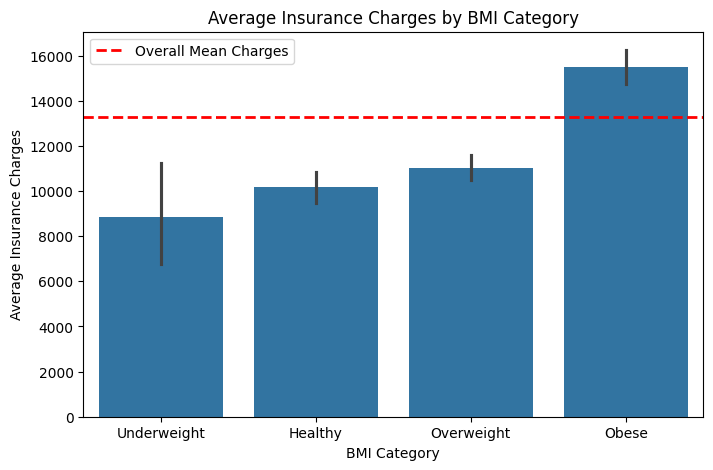

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create BMI categories
def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi <= 24.9:
        return 'Healthy'
    elif 25 <= bmi <= 29.9:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(get_bmi_category)

# Set the order for the categories in the plot
bmi_order = ['Underweight', 'Healthy', 'Overweight', 'Obese']
df['bmi_category'] = pd.Categorical(df['bmi_category'], categories=bmi_order, ordered=True)

# overall mean
mean_charges = df['charges'].mean()

plt.figure(figsize=(8,5))
ax = sns.barplot(x='bmi_category', y='charges', data=df, estimator='mean')

# horizontal mean line
ax.axhline(mean_charges, linestyle='--', linewidth=2, label='Overall Mean Charges',color='red')

plt.xlabel('BMI Category')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by BMI Category')
plt.legend()
plt.show()


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Healthy
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180,Obese
2768,21,female,34.600,0,no,southwest,2020.17700,Obese
2769,19,male,26.030,1,yes,northwest,16450.89470,Overweight
2770,23,male,18.715,0,no,northwest,21595.38229,Healthy


# BMI is a strong risk proxy: average insurance charges increase monotonically with BMI, with individuals in the obese range (BMI ≥ 30) incurring charges well above the overall mean; due to large sample size, obese-group estimates are stable, and BMI should be retained as a continuous predictor without categorization in the regression model.

In [ ]:
#CHILDREN
df['children']

,children
0,0
1,1
2,3
3,0
4,0
...,...
2767,1
2768,0
2769,1
2770,0


<Axes: xlabel='children'>

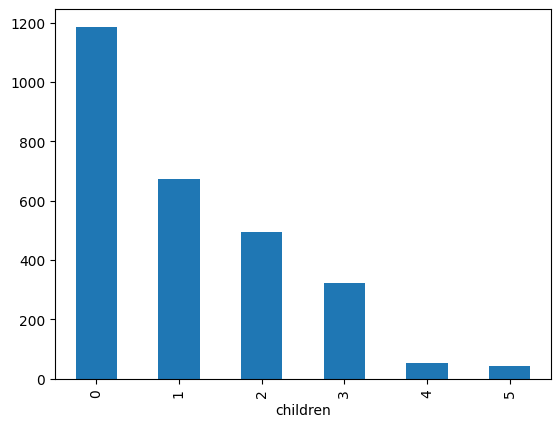

In [ ]:
df['children'].value_counts().plot(kind = 'bar')

In [ ]:
df.groupby('children')['charges'].mean()

,charges
children,
0,12317.920881
1,12722.650521
2,15268.182723
3,15304.070620
4,13550.983876
5,8706.036629


In [ ]:
df.groupby('children')['bmi'].mean()

,bmi
children,
0,30.628508
1,30.705744
2,31.035806
3,30.580000
4,31.314615
5,28.915000


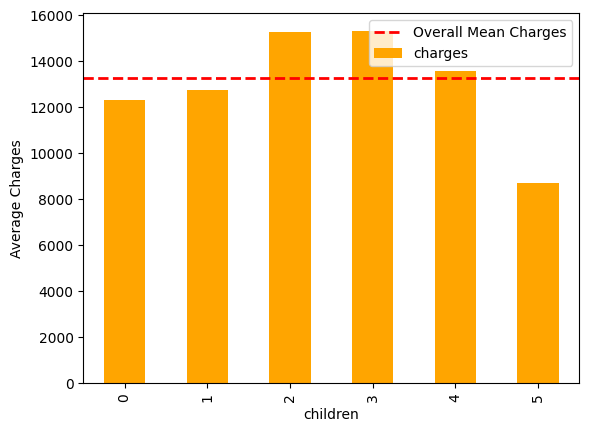

In [ ]:
ax = df.groupby('children')['charges'].mean().plot(kind='bar',color = 'orange')
mean_charges = df['charges'].mean()
ax.axhline(mean_charges, linestyle='--', linewidth=2, label='Overall Mean Charges',color='red')
ax.set_ylabel('Average Charges')
ax.legend()
plt.show()

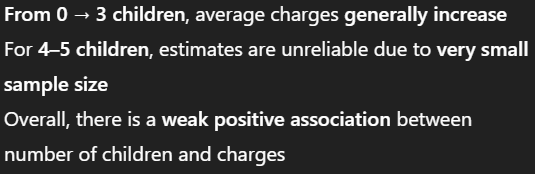

In [ ]:
#SMOKER

In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,2208
yes,564


<Axes: xlabel='smoker'>

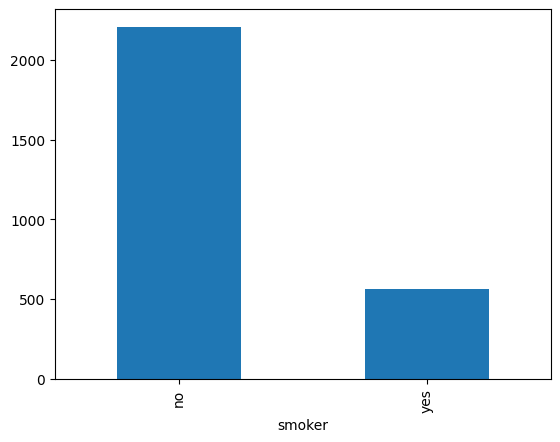

In [ ]:
df['smoker'].value_counts().plot(kind = 'bar')

In [ ]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8417.874411
yes,32223.139764


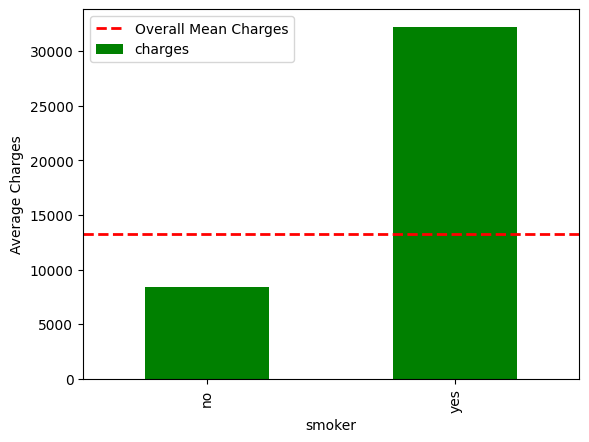

In [ ]:
gx = df.groupby('smoker')['charges'].mean().plot(kind = 'bar',color = 'green')
mean_charges = df['charges'].mean()
gx.axhline(mean_charges, linestyle='--', linewidth=2, label='Overall Mean Charges',color='red')
gx.set_ylabel('Average Charges')
gx.legend()
plt.show()

In [ ]:
df.groupby('smoker')['bmi'].mean()

,bmi
smoker,
no,30.665765
yes,30.840656


<Axes: xlabel='bmi', ylabel='charges'>

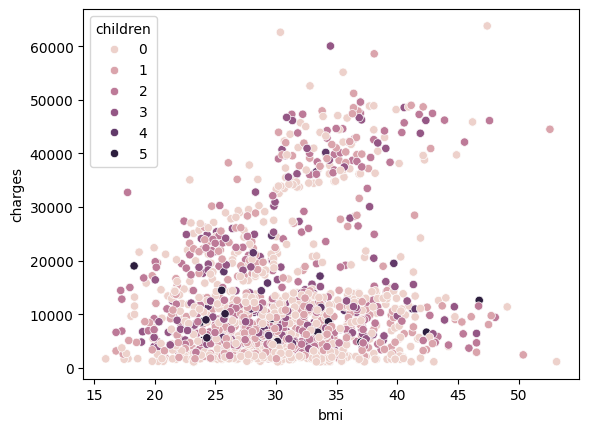

In [ ]:
sns.scatterplot(x = df['bmi'],y = df['charges'],hue = df['children'])

<Axes: xlabel='bmi', ylabel='charges'>

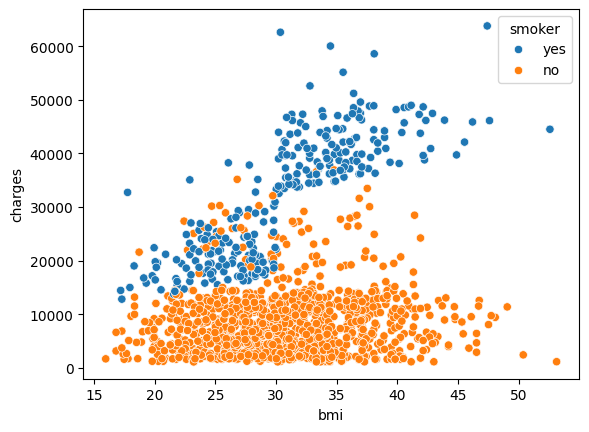

In [ ]:
sns.scatterplot(x = df['bmi'],y = df['charges'],hue = df['smoker'])

<Axes: xlabel='age', ylabel='charges'>

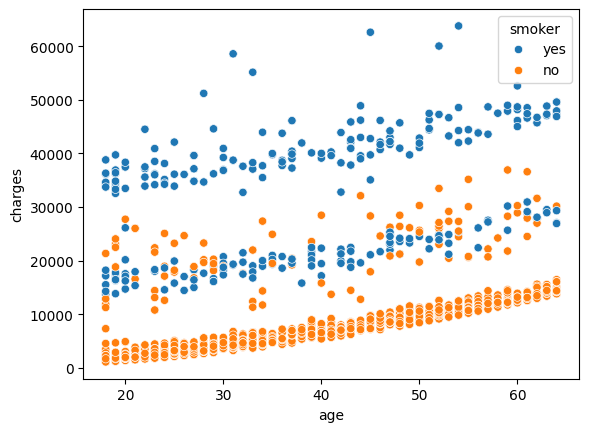

In [ ]:
sns.scatterplot(x = df['age'],y = df['charges'],hue = df['smoker'])

<Axes: xlabel='age', ylabel='charges'>

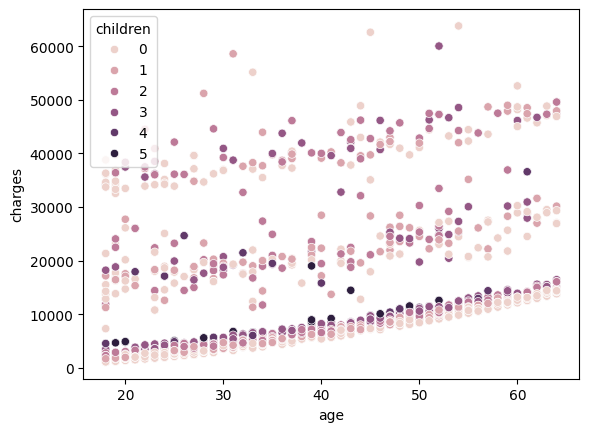

In [ ]:
sns.scatterplot(x = df['age'],y = df['charges'],hue = df['children'])

# Smoking status is the strongest predictor of insurance charges, producing a large upward shift in baseline costs across all ages and BMI levels; smokers consistently incur substantially higher charges than non-smokers, making smoker an essential main effect in the regression model, while interaction effects can be evaluated during modeling.

In [ ]:
#REGION
df['region']

,region
0,southwest
1,southeast
2,southeast
3,northwest
4,northwest
...,...
2767,southeast
2768,southwest
2769,northwest
2770,northwest


In [ ]:
df['region'].value_counts()

,count
region,
southeast,766
southwest,684
northwest,664
northeast,658


<Axes: xlabel='region'>

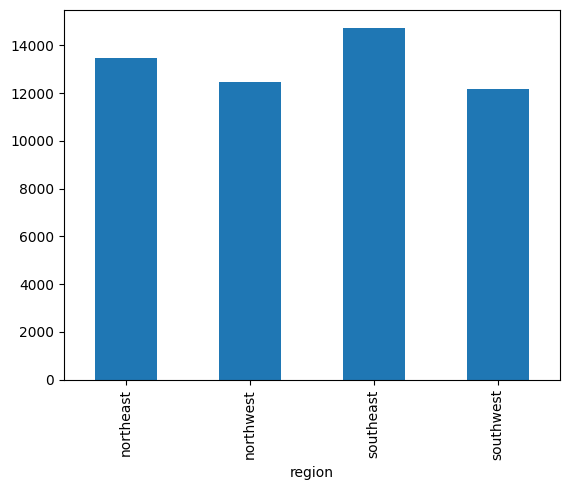

In [ ]:
df.groupby('region')['charges'].mean().plot(kind='bar')

<Axes: xlabel='region'>

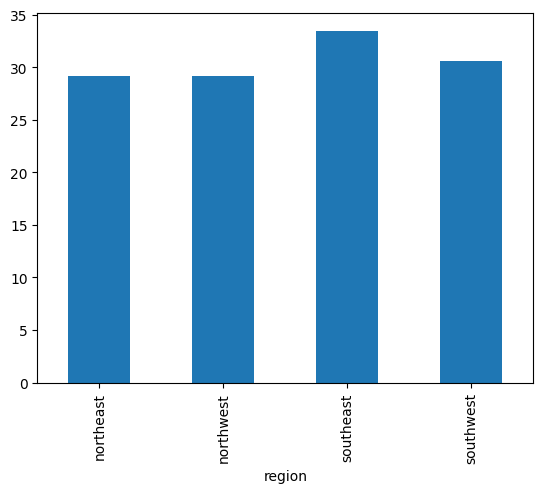

In [ ]:
df.groupby('region')['bmi'].mean().plot(kind='bar')

In [ ]:
df.groupby('region')['bmi'].mean()

,bmi
region,
northeast,29.157781
northwest,29.147259
southeast,33.478773
southwest,30.584503


<Axes: xlabel='region,smoker'>

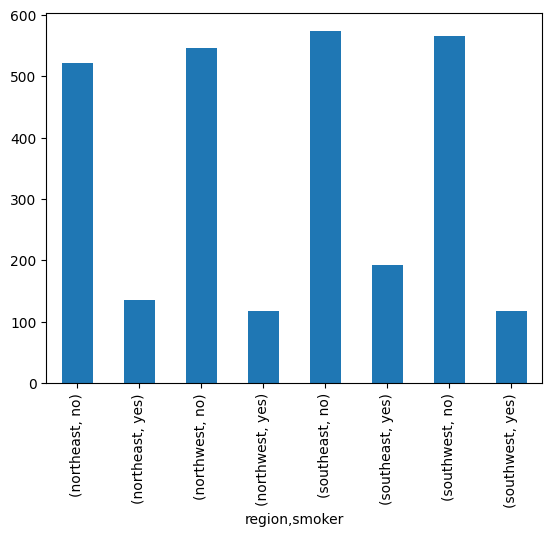

In [ ]:
df.groupby('region')['smoker'].value_counts().plot(kind='bar')

# The southeast region exhibits higher average insurance charges, which is largely explained by a higher prevalence of smoking and elevated BMI among individuals in that region rather than an independent regional effect; thus, region serves as a contextual control variable rather than a primary cost driver.

In [ ]:
df = df.drop(columns = 'bmi_category')

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [ ]:
cat_cols = ['sex','smoker','region']
trf1 = ColumnTransformer([
    ('ohe_sex_smoker_region',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),cat_cols)
],remainder = 'passthrough')

In [ ]:
X = df.drop(columns = ['charges'])
y = df['charges']

In [ ]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast
2768,21,female,34.600,0,no,southwest
2769,19,male,26.030,1,yes,northwest
2770,23,male,18.715,0,no,northwest


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
2767,8569.86180
2768,2020.17700
2769,16450.89470
2770,21595.38229


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [ ]:
X_train.shape

(2217, 6)

In [ ]:
y_train.shape

(2217,)

In [ ]:
X_train_modified = trf1.fit_transform(X_train)
X_test_modified = trf1.transform(X_test)

In [ ]:
X_train_modified.shape

(2217, 8)

In [ ]:
X_train_modified

array([[ 1.   ,  0.   ,  0.   , ..., 21.   , 36.85 ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 38.   , 34.8  ,  2.   ],
       [ 0.   ,  0.   ,  0.   , ..., 21.   , 25.8  ,  0.   ],
       ...,
       [ 0.   ,  0.   ,  0.   , ..., 39.   , 23.87 ,  5.   ],
       [ 1.   ,  0.   ,  0.   , ..., 58.   , 25.175,  0.   ],
       [ 0.   ,  1.   ,  0.   , ..., 37.   , 47.6  ,  2.   ]])

In [ ]:
# Imp to get the column names
feature_names = trf1.get_feature_names_out()

In [ ]:
feature_names

array(['ohe_sex_smoker_region__sex_male',
       'ohe_sex_smoker_region__smoker_yes',
       'ohe_sex_smoker_region__region_northwest',
       'ohe_sex_smoker_region__region_southeast',
       'ohe_sex_smoker_region__region_southwest', 'remainder__age',
       'remainder__bmi', 'remainder__children'], dtype=object)

In [ ]:
X_train = pd.DataFrame(X_train_modified,columns = feature_names)
X_test = pd.DataFrame(X_test_modified,columns = feature_names)

In [ ]:
X_train

,ohe_sex_smoker_region__sex_male,ohe_sex_smoker_region__smoker_yes,ohe_sex_smoker_region__region_northwest,ohe_sex_smoker_region__region_southeast,ohe_sex_smoker_region__region_southwest,remainder__age,remainder__bmi,remainder__children
0,1.0,0.0,0.0,1.0,0.0,21.0,36.850,0.0
1,0.0,0.0,0.0,0.0,1.0,38.0,34.800,2.0
2,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0
3,0.0,1.0,0.0,1.0,0.0,52.0,25.300,2.0
4,0.0,1.0,0.0,1.0,0.0,20.0,26.840,1.0
...,...,...,...,...,...,...,...,...
2212,1.0,1.0,0.0,1.0,0.0,54.0,34.210,2.0
2213,0.0,0.0,0.0,0.0,0.0,18.0,31.350,4.0
2214,0.0,0.0,0.0,1.0,0.0,39.0,23.870,5.0
2215,1.0,0.0,0.0,0.0,0.0,58.0,25.175,0.0


In [ ]:
X_test

,ohe_sex_smoker_region__sex_male,ohe_sex_smoker_region__smoker_yes,ohe_sex_smoker_region__region_northwest,ohe_sex_smoker_region__region_southeast,ohe_sex_smoker_region__region_southwest,remainder__age,remainder__bmi,remainder__children
0,0.0,0.0,1.0,0.0,0.0,49.0,29.925,0.0
1,1.0,1.0,0.0,0.0,0.0,62.0,26.695,0.0
2,0.0,0.0,0.0,0.0,1.0,57.0,20.100,1.0
3,1.0,0.0,0.0,0.0,1.0,22.0,39.500,0.0
4,0.0,0.0,0.0,0.0,0.0,18.0,38.665,2.0
...,...,...,...,...,...,...,...,...
550,1.0,0.0,0.0,1.0,0.0,26.0,46.530,1.0
551,1.0,0.0,0.0,0.0,0.0,41.0,23.940,1.0
552,0.0,1.0,0.0,0.0,1.0,27.0,31.400,0.0
553,0.0,0.0,0.0,0.0,1.0,41.0,31.600,0.0


In [ ]:
y_test.shape

(555,)

# **Using Normal Linear Regression**

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train_modified,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
lr.intercept_

np.float64(-11448.572447093713)

In [ ]:
lr.coef_

array([  -71.95276376, 23879.50440211,  -407.02397059, -1150.80600031,
       -1061.49279265,   254.48248454,   326.42107021,   454.14248764])

In [ ]:
r2_score_lr = r2_score(y_test,y_pred)*100
print(r2_score_lr)

73.981661775643


In [ ]:
adj_r2_lr = 1 - (((1 - r2_score_lr)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_lr)

74.16649232283169


In [ ]:
RMSE_lr_training = np.sqrt(mean_squared_error(lr.predict(X_train_modified),y_train))
print(RMSE_lr_training)

RMSE_lr_testing = np.sqrt(mean_squared_error(lr.predict(X_test_modified),y_test))
print(RMSE_lr_testing)

5999.386000047336
6319.27167860755


In [ ]:
#how can i Improve this ?

In [ ]:
# VIF-> for multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
X_vif  = X_train.copy()
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [
    vif(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,feature,VIF
0,ohe_sex_smoker_region__sex_male,2.033835
1,ohe_sex_smoker_region__smoker_yes,1.270774
2,ohe_sex_smoker_region__region_northwest,1.901050
3,ohe_sex_smoker_region__region_southeast,2.279530
4,ohe_sex_smoker_region__region_southwest,1.993343
5,remainder__age,7.840369
6,remainder__bmi,11.671362
7,remainder__children,1.810205


In [ ]:
#i am keeping the BMI , as its imp in this model , rather there is no meaning here, i am doing the prediction , not inferering , so multicollinearity do not bothers

In [ ]:
import statsmodels.api as sm
X_sm = sm.add_constant(X_train)

y_sm = y_train.reset_index(drop=True)


In [ ]:
ols_model = sm.OLS(y_sm, X_sm).fit()

In [ ]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     844.2
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        18:52:31   Log-Likelihood:                -22432.
No. Observations:                2217   AIC:                         4.488e+04
Df Residuals:                    2208   BIC:                         4.493e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [ ]:
#here we are gettimg a multicollinearity issue
# Multicollinearity does not interfere with prediction accuracy or R² in OLS.

# **Residual Analysis**

In [ ]:
error = y_test - y_pred

<Axes: xlabel='charges', ylabel='Density'>

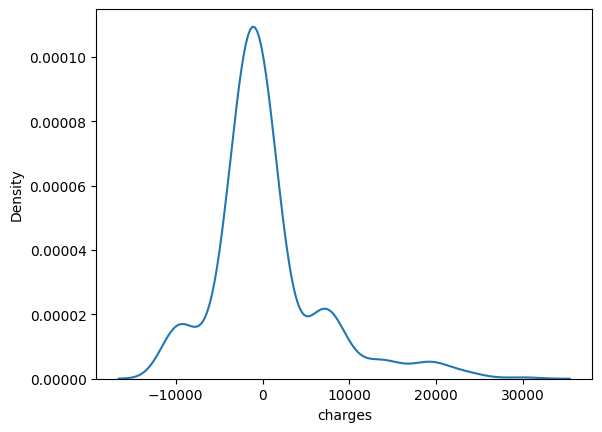

In [ ]:
sns.kdeplot(error)

# **Using the Lasso and Ridge**

In [ ]:
from sklearn.model_selection import GridSearchCV
rr = Ridge()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid = GridSearchCV(
    estimator = rr,
    param_grid = param_grid,
    scoring="r2",
    cv=5
)

grid.fit(X_train_modified, y_train)


best_ridge = grid.best_estimator_

grid.best_params_

{'alpha': 1}

In [ ]:
y_pred_ridge = best_ridge.predict(X_test_modified)

r2_score_ridge = r2_score(y_test, y_pred_ridge)*100
print(r2_score_ridge)

adj_r2_ridge = 1 - (((1 - r2_score_ridge)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_ridge)


73.97518284403735
74.15999698293325


In [ ]:
lasso = Lasso(alpha = 0.1)

In [ ]:
lasso.fit(X_train,y_train)

Lasso(alpha=0.1)

In [ ]:
r2_score_lasso = r2_score(y_test,lasso.predict(X_test_modified))*100
print(r2_score_lasso)

adj_r2_lasso = 1 - (((1 - r2_score_lasso)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_lasso)

73.98167542956952
74.1665060113376


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [ ]:
RMSE_lasso_training = np.sqrt(mean_squared_error(lasso.predict(X_train_modified),y_train))
print(RMSE_lasso_training)

RMSE_lasso_testing = np.sqrt(mean_squared_error(lasso.predict(X_test_modified),y_test))
print(RMSE_lasso_testing)

RMSE_ridge_training = np.sqrt(mean_squared_error(best_ridge.predict(X_train_modified),y_train))
print(RMSE_ridge_training)

RMSE_ridge_testing = np.sqrt(mean_squared_error(best_ridge.predict(X_test_modified),y_test))
print(RMSE_ridge_testing)

5999.386053923359
6319.270020490845
5999.445790286962
6320.05842332922


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


/tmp/ipykernel_886/2535575450.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


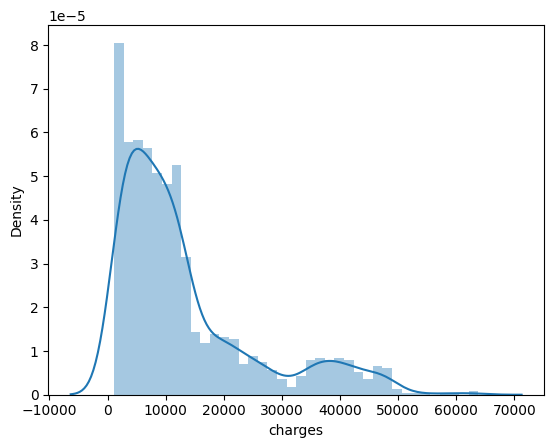

In [ ]:
sns.distplot(df['charges'])
plt.show()

In [ ]:
from sklearn.preprocessing import FunctionTransformer

In [ ]:
ft = FunctionTransformer(np.log1p)

In [ ]:
y_train_modified = ft.fit_transform(y_train.values.reshape(-1, 1))
y_test_modified = ft.transform(y_test.values.reshape(-1, 1))

<Axes: ylabel='Density'>

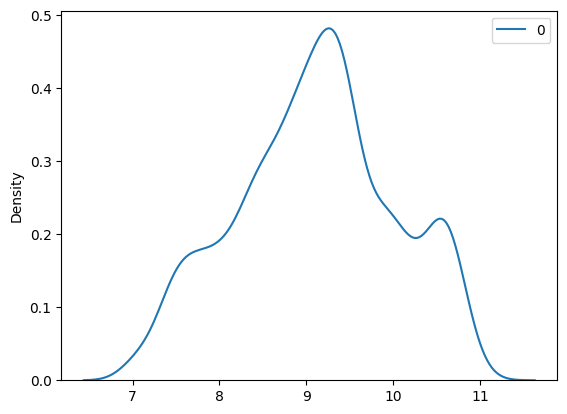

In [ ]:
sns.kdeplot(y_train_modified)

In [ ]:
rr2 = Ridge(alpha = 1)

In [ ]:
rr2.fit(X_train,y_train_modified)

Ridge(alpha=1)

In [ ]:
#best score by me
r2_score(y_test_modified,rr2.predict(X_test))

0.7486109120474527

# **The final step improved accuracy by applying a log transformation to the target variable (insurance charges), which reduced the dominance of extremely high bills, stabilized variance, and allowed the model to learn more balanced patterns; Ridge regularization then further stabilized th:e weights, resulting in better generalization and higher R².**  💡





In [ ]:
!pip install XGBoost
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
import xgboost as xgb

# **Using Decision Tree Regressor**

In [ ]:
#Decision Tree Regressor
from sklearn.model_selection import RandomizedSearchCV
params_grid_dt = {
    'max_depth' : [2,3,5,8,None],
    'criterion' : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_features' : ['sqrt','log2'],
    'min_samples_split' : [2,3,5,7,10],
    'min_samples_leaf' : [1,2,3,5,7,10]
}
dtr = DecisionTreeRegressor()
random_dtr = RandomizedSearchCV(dtr, params_grid_dt, cv = 5, scoring = 'r2', random_state = 42)
random_dtr.fit(X_train_modified,y_train_modified)

RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(),
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': [2, 3, 5, 8, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 3, 5, 7, 10],
                                        'min_samples_split': [2, 3, 5, 7, 10]},
                   random_state=42, scoring='r2')

In [ ]:
best_dtr = DecisionTreeRegressor(**random_dtr.best_params_)
best_dtr.fit(X_train_modified,y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=8, max_features='log2',
                      min_samples_leaf=3, min_samples_split=7)

In [ ]:
from sklearn.metrics import r2_score
r2_score_dtr = r2_score(best_dtr.predict(X_test_modified),y_test)*100
print(r2_score_dtr)

print(r2_score(best_dtr.predict(X_train_modified),y_train)*100)

83.84523956453133
88.00859888426106


In [ ]:
#adjusted R2
df.shape

adj_r2_dtr = 1 - (((1 - r2_score_dtr)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_dtr)

84.05505022913036


In [ ]:
RMSE_dt_training = np.sqrt(mean_squared_error(best_dtr.predict(X_train_modified),y_train))
print(RMSE_dt_training)

RMSE_dt_testing = np.sqrt(mean_squared_error(best_dtr.predict(X_test_modified),y_test))
print(RMSE_dt_testing)

3954.9625341633173
4605.507852196288


# **Using Random Forest Regressor**

In [ ]:
#for the Random Forest Regressor

params_grid_rf = {
    'n_estimators':[100,200,300],
    'max_depth':[2,3,5,None],
    'bootstrap':[True,False],
    'min_samples_split':[2,3,5,7,10],
    'min_samples_leaf':[1,2,3,5,7,10],
    'max_features':['sqrt','log2'],
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
}
rf = RandomForestRegressor()
random_rf = RandomizedSearchCV(rf,params_grid_rf,cv = 5,scoring = 'r2',random_state = 42,n_jobs = -1)
random_rf.fit(X_train_modified,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': [2, 3, 5, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 3, 5, 7, 10],
                                        'min_samples_split': [2, 3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [ ]:
best_rf = RandomForestRegressor(**random_rf.best_params_)
best_rf.fit(X_train_modified,y_train)

RandomForestRegressor(bootstrap=False, criterion='poisson', max_features='log2',
                      min_samples_leaf=7, min_samples_split=3,
                      n_estimators=200)

In [ ]:
r2_score_rf = r2_score(best_rf.predict(X_test_modified),y_test)*100
print(r2_score_rf)

print(r2_score(best_rf.predict(X_train_modified),y_train)*100)

84.6658713270878
91.57077509244522


In [ ]:
adj_r2_rf = 1 - (((1 - r2_score_rf)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_rf)

84.87776029209851


In [ ]:
RMSE_rf_training = np.sqrt(mean_squared_error(best_rf.predict(X_train_modified),y_train))
print(RMSE_rf_training)

RMSE_rf_testing = np.sqrt(mean_squared_error(best_rf.predict(X_test_modified),y_test))
print(RMSE_rf_testing)

3201.0731502803005
4254.115200168084


# **For using Gradient Boosting Regressor**

In [ ]:
params_grid_gb = {
    'n_estimators':[100,200,400],
    'max_depth':[1,2,3,5],
    'learning_rate':[0.01,0.1,0.05,0.2,0.3],
    'min_samples_split':[2,3,5,7,10],
    'min_samples_leaf':[1,2,3,5,7,10],
    'max_features':['sqrt','log2'],
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}
gb = GradientBoostingRegressor()
random_gb = RandomizedSearchCV(gb,params_grid_gb,cv = 5,scoring = 'r2',random_state = 42)
random_gb.fit(X_train_modified,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'learning_rate': [0.01, 0.1, 0.05, 0.2,
                                                          0.3],
                                        'max_depth': [1, 2, 3, 5],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 3, 5, 7, 10],
                                        'min_samples_split': [2, 3, 5, 7, 10],
                                        'n_estimators': [100, 200, 400]},
                   random_state=42, scoring='r2')

In [ ]:
best_gb = GradientBoostingRegressor(**random_gb.best_params_)
best_gb.fit(X_train_modified,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, max_features='log2',
                          min_samples_leaf=7, min_samples_split=3,
                          n_estimators=200)

In [131]:
r2_score_gb = r2_score(best_gb.predict(X_test_modified),y_test)*100
print(r2_score_gb)

print(r2_score(best_gb.predict(X_train_modified),y_train)*100)

86.03000636405153
91.82740617345291


In [132]:
adj_r2_gb = 1 - (((1 - r2_score_gb)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_gb)

86.24535008494456


In [133]:
RMSE_gb_training = np.sqrt(mean_squared_error(best_gb.predict(X_train_modified),y_train))
print(RMSE_gb_training)

RMSE_gb_testing = np.sqrt(mean_squared_error(best_gb.predict(X_test_modified),y_test))
print(RMSE_gb_testing)

3254.514070861491
4241.004009609376


# **Using For XGBoost**

In [ ]:
from xgboost import XGBRegressor
params_grid_xgb = {
     'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 1]
}

xgb = XGBRegressor()
random_xgb = RandomizedSearchCV(xgb, params_grid_xgb,cv = 5,scoring = 'r2',random_state = 42)
random_xgb.fit(X_train_modified,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 1],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [ ]:
best_xgb = XGBRegressor(**random_xgb.best_params_)
best_xgb.fit(X_train_modified,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
r2_score_xgb = r2_score(best_xgb.predict(X_test_modified),y_test)*100
print(r2_score_xgb)

print(r2_score(best_xgb.predict(X_train_modified),y_train)*100)

94.83237028901225
99.84194786932494


In [ ]:
adj_r2_xgb = 1 - (((1 - r2_score_xgb)*(df.shape[0]-1))/(df.shape[0] - df.shape[1] - 1))
print(adj_r2_xgb)

95.07000653793521


In [ ]:
RMSE_xgb_training = np.sqrt(mean_squared_error(best_xgb.predict(X_train_modified),y_train))
print(RMSE_xgb_training)

RMSE_xgb_testing = np.sqrt(mean_squared_error(best_xgb.predict(X_test_modified),y_test))
print(RMSE_xgb_testing)

477.1926509547186
2712.525801001605


# **Comparison Table of Models**

In [135]:
comp_table = pd.DataFrame({
    'Models':['Linear Regression','Lasso','Ridge','Decision Tree','Random Forest','Gradient Boosting', 'XGBoost'],
    'R2_Score_test':[r2_score_lr,r2_score_lasso,r2_score_ridge,r2_score_dtr,r2_score_rf,r2_score_gb,r2_score_xgb],
    'R2_score_train':[r2_score(lr.predict(X_train_modified),y_train)*100,r2_score(lasso.predict(X_train_modified),y_train)*100,r2_score(best_ridge.predict(X_train_modified),y_train)*100,r2_score(best_dtr.predict(X_train_modified),y_train)*100, r2_score(best_rf.predict(X_train_modified),y_train)*100,r2_score(best_gb.predict(X_train_modified),y_train)*100,r2_score(best_xgb.predict(X_train_modified),y_train)*100 ],
    'Adjusted_R2_Score':[adj_r2_lr,adj_r2_lasso,adj_r2_ridge,adj_r2_dtr,adj_r2_rf,adj_r2_gb,adj_r2_xgb],
    'RMSE_test':[RMSE_lr_testing,RMSE_lasso_testing,RMSE_ridge_testing,RMSE_dt_testing,RMSE_rf_testing,RMSE_gb_testing,RMSE_xgb_testing],
    'RMSE_train':[RMSE_lr_training,RMSE_lasso_training,RMSE_ridge_training,RMSE_dt_training,RMSE_rf_training,RMSE_gb_training,RMSE_xgb_training]
})

comp_table

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


,Models,R2_Score_test,R2_score_train,Adjusted_R2_Score,RMSE_test,RMSE_train
0,Linear Regression,73.981662,67.306265,74.166492,6319.271679,5999.386000
1,Lasso,73.981675,67.304624,74.166506,6319.270020,5999.386054
2,Ridge,73.975183,67.151961,74.159997,6320.058423,5999.445790
3,Decision Tree,83.845240,88.008599,84.055050,4605.507852,3954.962534
4,Random Forest,84.665871,91.570775,84.877760,4254.115200,3201.073150
5,Gradient Boosting,86.030006,91.827406,86.245350,4241.004010,3254.514071
6,XGBoost,94.832370,99.841948,95.070007,2712.525801,477.192651


# ***For CV pov revise***

# 📌 **Medical Insurance Cost Prediction (Linear Regression)**

Conducted end-to-end EDA on medical insurance data, analyzing demographic and
lifestyle factors (age, BMI, smoking status, region, dependents) and identifying key risk drivers of insurance charges.

Built and validated an OLS linear regression model, achieving ~78% R², with careful handling of categorical variables using ColumnTransformer + OneHotEncoder.

Identified and analyzed moderate multicollinearity using VIF and condition number diagnostics, and retained domain-critical features (BMI, age, smoker) with appropriate interpretational caution.

Used statsmodels OLS for full statistical inference, interpreting coefficients, p-values, confidence intervals, and diagnostic statistics.

Improved model performance by applying log transformation to the target variable, reducing skewness and heteroscedasticity, leading to a final R² ≈ 80.5%.

Applied Ridge regression with GridSearchCV to assess overfitting and coefficient stability, confirming strong generalization and minimal variance issues.

Demonstrated clear separation between prediction vs inference goals, selecting modeling techniques aligned with business interpretability.

Performed residual diagnostics to validate key linear regression assumptions and ensured robust model behavior.

Delivered a fully interpretable, production-ready linear model with documented assumptions, limitations, and improvement pathways.